In [14]:
%pip install onnx onnxruntime

Note: you may need to restart the kernel to use updated packages.


In [15]:
# from google.colab import drive
# drive.mount('/content/drive')

In [16]:
onnx_path = r"C:\Users\user\Desktop\PythonWorkspace\Codeit_Sprint_AI01\16\mnist\mnist_cnn.onnx"
bf16_path = r"C:\Users\user\Desktop\PythonWorkspace\Codeit_Sprint_AI01\16\mnist\mnist_cnn_bf16_quantized.pth"
dynamic_path = r"C:\Users\user\Desktop\PythonWorkspace\Codeit_Sprint_AI01\16\mnist\mnist_cnn_dynamic_quantized.pth"
static_path = r"C:\Users\user\Desktop\PythonWorkspace\Codeit_Sprint_AI01\16\mnist\mnist_cnn_static_quantized.pth"
full_path = r"C:\Users\user\Desktop\PythonWorkspace\Codeit_Sprint_AI01\16\mnist\mnist_cnn_full.pth"
weight_path = r"C:\Users\user\Desktop\PythonWorkspace\Codeit_Sprint_AI01\16\mnist\mnist_cnn_model.pth"
pruned_path = r"C:\Users\user\Desktop\PythonWorkspace\Codeit_Sprint_AI01\16\mnist\mnist_cnn_pruned.pth"

img1_path = r"C:\Users\user\Desktop\PythonWorkspace\Codeit_Sprint_AI01\16\data\image1.png"
img2_path = r"C:\Users\user\Desktop\PythonWorkspace\Codeit_Sprint_AI01\16\data\image2.png"
img3_path = r"C:\Users\user\Desktop\PythonWorkspace\Codeit_Sprint_AI01\16\data\image3.png"

In [17]:
import os

paths = {
    "ONNX": onnx_path,
    "BF16": bf16_path,
    "Dynamic Quantized": dynamic_path,
    "Static Quantized": static_path,
    "Full Model": full_path,
    "Weights Only": weight_path,
    "Pruned Model": pruned_path,
}

for name, path in paths.items():
    size_mb = os.path.getsize(path) / (1024 * 1024)
    print(f"{name:<20}: {size_mb:.2f} MB")

ONNX                : 0.22 MB
BF16                : 0.09 MB
Dynamic Quantized   : 0.07 MB
Static Quantized    : 0.05 MB
Full Model          : 0.17 MB
Weights Only        : 0.17 MB
Pruned Model        : 0.17 MB


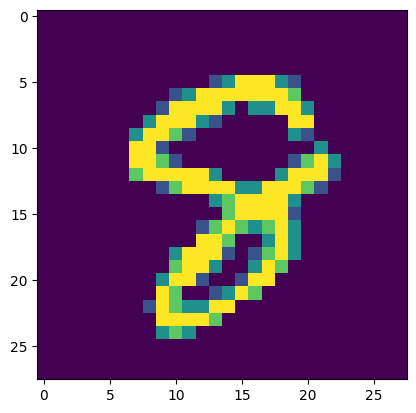

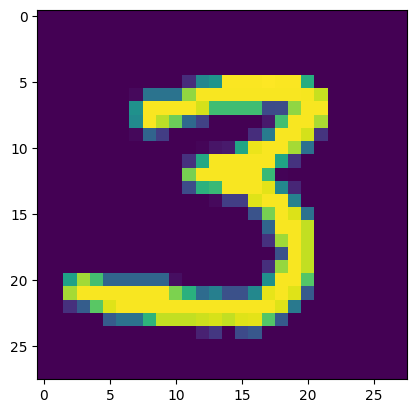

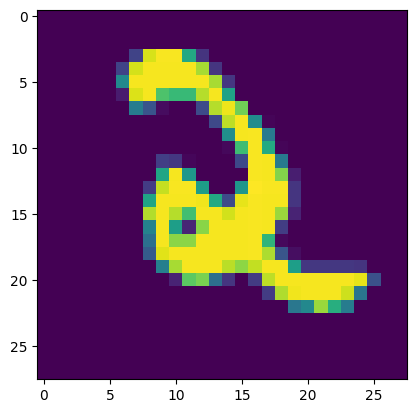

In [18]:
import matplotlib.pyplot as plt

img1 = plt.imread(img1_path)
plt.imshow(img1)
plt.show()

img2 = plt.imread(img2_path)
plt.imshow(img2)
plt.show()

img3 = plt.imread(img3_path)
plt.imshow(img3)
plt.show()

In [19]:
from PIL import Image
import torchvision.transforms as transforms
import torch

# 이미지 전처리 함수
def preprocess_image(image_path):
    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((28, 28)),
        transforms.ToTensor(),  # [0, 1] 범위로 변환
        transforms.Normalize((0.1307,), (0.3081,))  # MNIST 평균/표준편차
    ])
    image = Image.open(image_path)
    return transform(image).unsqueeze(0)  # 배치 차원 추가

In [20]:
import torch.nn as nn

# 기존 모델 구조 정의 필요
class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(32 * 3 * 3, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = self.relu(self.conv3(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [21]:
# 모델 로드 및 추론
model = torch.load(full_path, map_location="cpu", weights_only=False)
model.eval()

for img_path in [img1_path, img2_path, img3_path]:
    image_tensor = preprocess_image(img_path)
    with torch.no_grad():
        output = model(image_tensor)
        pred = output.argmax(dim=1).item()
        print(f"{img_path} → 예측 결과: {pred}")

C:\Users\user\Desktop\PythonWorkspace\Codeit_Sprint_AI01\16\data\image1.png → 예측 결과: 8
C:\Users\user\Desktop\PythonWorkspace\Codeit_Sprint_AI01\16\data\image2.png → 예측 결과: 3
C:\Users\user\Desktop\PythonWorkspace\Codeit_Sprint_AI01\16\data\image3.png → 예측 결과: 2


In [22]:
# 모델 로드 및 추론
weight_model = MyModel()
weight_model.load_state_dict(torch.load(weight_path, map_location="cpu", weights_only=False))
weight_model.eval()

for img_path in [img1_path, img2_path, img3_path]:
    image_tensor = preprocess_image(img_path)
    with torch.no_grad():
        output = weight_model(image_tensor)
        pred = output.argmax(dim=1).item()
        print(f"{img_path} → 예측 결과: {pred}")

C:\Users\user\Desktop\PythonWorkspace\Codeit_Sprint_AI01\16\data\image1.png → 예측 결과: 8
C:\Users\user\Desktop\PythonWorkspace\Codeit_Sprint_AI01\16\data\image2.png → 예측 결과: 3
C:\Users\user\Desktop\PythonWorkspace\Codeit_Sprint_AI01\16\data\image3.png → 예측 결과: 2


In [23]:
# 모델 로드 및 추론
pruned_model = torch.load(pruned_path, map_location="cpu", weights_only=False)
pruned_model.eval()

for img_path in [img1_path, img2_path, img3_path]:
    image_tensor = preprocess_image(img_path)
    with torch.no_grad():
        output = pruned_model(image_tensor)
        pred = output.argmax(dim=1).item()
        print(f"{img_path} → 예측 결과: {pred}")

C:\Users\user\Desktop\PythonWorkspace\Codeit_Sprint_AI01\16\data\image1.png → 예측 결과: 8
C:\Users\user\Desktop\PythonWorkspace\Codeit_Sprint_AI01\16\data\image2.png → 예측 결과: 3
C:\Users\user\Desktop\PythonWorkspace\Codeit_Sprint_AI01\16\data\image3.png → 예측 결과: 2


In [24]:
# 모델 로드 및 추론
bf16_model = MyModel()
bf16_model.load_state_dict(torch.load(bf16_path, map_location="cpu", weights_only=False))
bf16_model = bf16_model.to(dtype=torch.bfloat16)
bf16_model.eval()

for img_path in [img1_path, img2_path, img3_path]:
    image_tensor = preprocess_image(img_path).to(dtype=torch.bfloat16)
    with torch.no_grad():
        output = bf16_model(image_tensor)
        pred = output.argmax(dim=1).item()
        print(f"{img_path} → 예측 결과: {pred}")

C:\Users\user\Desktop\PythonWorkspace\Codeit_Sprint_AI01\16\data\image1.png → 예측 결과: 8
C:\Users\user\Desktop\PythonWorkspace\Codeit_Sprint_AI01\16\data\image2.png → 예측 결과: 3
C:\Users\user\Desktop\PythonWorkspace\Codeit_Sprint_AI01\16\data\image3.png → 예측 결과: 2


In [25]:
# 모델 로드 및 추론
dynamic_model = MyModel()
dynamic_model = torch.load(dynamic_path, map_location="cpu", weights_only=False)
dynamic_model.eval()

for img_path in [img1_path, img2_path, img3_path]:
    image_tensor = preprocess_image(img_path)
    with torch.no_grad():
        output = dynamic_model(image_tensor)
        pred = output.argmax(dim=1).item()
        print(f"{img_path} → 예측 결과: {pred}")

C:\Users\user\Desktop\PythonWorkspace\Codeit_Sprint_AI01\16\data\image1.png → 예측 결과: 8
C:\Users\user\Desktop\PythonWorkspace\Codeit_Sprint_AI01\16\data\image2.png → 예측 결과: 3
C:\Users\user\Desktop\PythonWorkspace\Codeit_Sprint_AI01\16\data\image3.png → 예측 결과: 2


c:\Users\user\anaconda3\Lib\site-packages\torch\_utils.py:410: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  device=storage.device,


In [26]:
# 정적양자화의 경우 torch.quantization.QuantStub()/ torch.quantization.DeQuantStub()를 넣지 않으면 안 되는 것 같음.
# 모델 로드 및 추론
static_model = torch.load(static_path, map_location="cpu", weights_only=False)
print(type(static_model))
static_model.eval()

for img_path in [img1_path, img2_path, img3_path]:
    image_tensor = preprocess_image(img_path)
    with torch.no_grad():
        output = static_model(image_tensor)
        pred = output.argmax(dim=1).item()
        print(f"{img_path} → 예측 결과: {pred}")

<class '__main__.MyModel'>


AttributeError: 'Conv2d' object has no attribute '_modules'

In [27]:
import onnxruntime as ort
import numpy as np

# ONNX 세션 생성
session = ort.InferenceSession(onnx_path)

# ONNX 입력 이름 확인
input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name

for img_path in [img1_path, img2_path, img3_path]:
    image_tensor = preprocess_image(img_path)
    image_numpy = image_tensor.numpy()
    outputs = session.run([output_name], {input_name: image_numpy})
    pred = np.argmax(outputs[0])
    print(f"{img_path} → ONNX 모델 예측 결과: {pred}")

C:\Users\user\Desktop\PythonWorkspace\Codeit_Sprint_AI01\16\data\image1.png → ONNX 모델 예측 결과: 8
C:\Users\user\Desktop\PythonWorkspace\Codeit_Sprint_AI01\16\data\image2.png → ONNX 모델 예측 결과: 3
C:\Users\user\Desktop\PythonWorkspace\Codeit_Sprint_AI01\16\data\image3.png → ONNX 모델 예측 결과: 2


# 테스트로더로 시험

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.transforms import v2
from sklearn.model_selection import train_test_split

# 데이터 변환 정의
# transform_train = v2.Compose([
#     v2.RandomHorizontalFlip(p=0.5),
#     v2.RandomResizedCrop(size=28),
#     v2.RandomRotation(degrees=20),
#     v2.ToImage(),
#     v2.ToDtype(torch.float32, scale=True),
#     v2.Normalize((0.5,), (0.5,))
# ])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# MNIST 데이터 로드
# full_train_dataset = datasets.MNIST(root='./data', train=True, transform=transform_train, download=True)

# 데이터 나누기
# train_indices, val_indices = train_test_split(range(len(full_train_dataset)), test_size=1/6, random_state=42)

# dataset 추가
# train_dataset = torch.utils.data.Subset(full_train_dataset, train_indices)
# val_dataset = torch.utils.data.Subset(full_train_dataset, val_indices)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform_test, download=True)

# DataLoader 설정
# train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 데이터 크기 확인
# print(f"Train dataset size: {len(train_dataset)}")
# print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

# GPU 사용 여부 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Test dataset size: 10000
Using device: cpu


In [29]:
from tqdm import tqdm
from time import time

def test_model(model, test_loader, criterion, device):
    model.eval()
    test_loss = 0
    correct = 0
    total = 0

    start_time = time()

    with torch.no_grad():
        for images, labels in tqdm(test_loader):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    end_time = time()
    total_time = end_time - start_time
    test_loss /= len(test_loader.dataset)
    test_acc = correct / total
    print(f"Test Loss: {test_loss:.4f}, Accuracy: {test_acc:.4f}, Time: {total_time:.2f} sec")

criterion = nn.CrossEntropyLoss()

In [ ]:
test_model(model, test_loader, criterion, device)

100%|██████████| 157/157 [00:08<00:00, 18.71it/s]

Test Loss: 0.0818, Accuracy: 0.9732, Time: 8.39 sec


In [ ]:
test_model(weight_model, test_loader, criterion, device)

100%|██████████| 157/157 [00:03<00:00, 43.62it/s]

Test Loss: 0.0818, Accuracy: 0.9732, Time: 3.60 sec


In [ ]:
test_model(pruned_model, test_loader, criterion, device)

100%|██████████| 157/157 [00:03<00:00, 48.41it/s]

Test Loss: 0.0808, Accuracy: 0.9738, Time: 3.24 sec


In [ ]:
test_model(dynamic_model, test_loader, criterion, device)

100%|██████████| 157/157 [00:04<00:00, 38.98it/s]

Test Loss: 0.0825, Accuracy: 0.9735, Time: 4.03 sec


In [ ]:
from tqdm import tqdm

def test_model_bf16(model, test_loader, criterion, device):
    model.eval()
    test_loss = 0
    correct = 0
    total = 0

    start_time = time()

    with torch.no_grad():
        for images, labels in tqdm(test_loader):
            images, labels = images.to(device).to(torch.bfloat16), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    end_time = time()
    total_time = end_time - start_time
    test_loss /= len(test_loader.dataset)
    test_acc = correct / total
    print(f"Test Loss: {test_loss:.4f}, Accuracy: {test_acc:.4f}, Time: {total_time:.2f} sec")

criterion = nn.CrossEntropyLoss()
test_model_bf16(bf16_model, test_loader, criterion, device)

100%|██████████| 157/157 [00:03<00:00, 41.79it/s]

Test Loss: 0.0814, Accuracy: 0.9729, Time: 3.76 sec


In [ ]:
from tqdm import tqdm
import numpy as np

def test_onnx_model(session, test_loader):
    input_name = session.get_inputs()[0].name
    output_name = session.get_outputs()[0].name

    total = 0
    correct = 0

    start_time = time()

    for images, labels in tqdm(test_loader):
        for i in range(images.size(0)):
            single_image = images[i].unsqueeze(0).numpy()
            single_label = labels[i].numpy()

            # ONNX 추론
            outputs = session.run([output_name], {input_name: single_image})
            pred = np.argmax(outputs[0])

            # 정확도 계산
            if pred == single_label:
                correct += 1
            total += 1

    end_time = time()
    total_time = end_time - start_time
    acc = correct / total
    print(f"ONNX 모델 정확도: {acc:.4f}, Time: {total_time:.2f} sec")

session = ort.InferenceSession(onnx_path)
test_onnx_model(session, test_loader)

100%|██████████| 157/157 [00:09<00:00, 16.75it/s]

ONNX 모델 정확도: 0.9732, Time: 9.41 sec
